## Datos de Apophis

### Fundamento Teórico del Modelo de N-Cuerpos

Este notebook implementa la resolución numérica del **problema de N-cuerpos** en el marco de la mecánica celeste newtoniana, utilizando condiciones iniciales reales obtenidas del servicio JPL Horizons (NASA) para el Sol, la Tierra, la Luna, Júpiter y el asteroide Apophis.

#### 1. Ecuaciones de Movimiento 

El modelo se basa en la Ley de Gravitación Universal. Para un sistema de $N$ partículas, la aceleración de un cuerpo $i$ debida a la influencia gravitatoria de todos los demás cuerpos $j$ está dada por:

$$\frac{d^2\mathbf{r}_i}{dt^2} = -G \sum_{j \neq i}^{N} m_j \frac{\mathbf{r}_i - \mathbf{r}_j}{\|\mathbf{r}_i - \mathbf{r}_j\|^3}$$

Donde:
* $\mathbf{r}_i$: Vector de posición del cuerpo $i$.
* $G$: Constante de gravitación universal.
* $(\mathbf{r}_i - \mathbf{r}_j)$: Vector que define la dirección de la fuerza, apuntando desde el cuerpo $j$ hacia el cuerpo $i$.



#### 2. Unidades Canónicas y Normalización

Para mejorar la estabilidad numérica y evitar errores de precisión al trabajar con órdenes de magnitud extremos (como $10^{30}$ kg o $10^{11}$ m), el código transforma las magnitudes del Sistema Internacional (SI) a **unidades canónicas**:

* **Unidad de Longitud ($UL$):** $1$ Unidad Astronómica (AU).
* **Unidad de Masa ($UM$):** $1$ Masa Solar ($M_{\odot}$).
* **Unidad de Tiempo ($UT$):** Se define mediante la tercera ley de Kepler, de modo que la constante gravitacional en el sistema simulación sea $G_c = 1$.

#### 3. Integración Numérica: Algoritmo IAS15

La dinámica se integra con `IAS15` (REBOUND), un integrador adaptativo de alta precisión apropiado para problemas gravitacionales con escalas temporales muy distintas (la Luna orbita la Tierra en 27 días, mientras Júpiter tarda 12 años).

#### 4. Energía Mecánica Total del Sistema

La energía total $E$ se calcula:

$$E = K + U$$

* **Energía Cinética ($K$):** $$K = \frac{1}{2} \sum_{i} m_i \|\mathbf{v}_i\|^2$$
* **Energía Potencial Gravitatoria ($U$):** $$U = -\sum_{i < j} \frac{G_c m_i m_j}{\|\mathbf{r}_i - \mathbf{r}_j\|}$$

#### 5. Sistema de Referencia

El código utiliza la función `sim.move_to_com()` para trasladar el origen de coordenadas al **Centro de Masa (Baricentro)** del sistema:
$$\mathbf{R}_{COM} = \frac{\sum m_i \mathbf{r}_i}{\sum m_i}$$
Esto asegura que el sistema no presente un desplazamiento del sistema completo a través del espacio debido a errores numéricos o a una mala elección del sistema de referencia.

Unidades canonicas:
  UL = 1.495979e+11 m
  UM = 1.988470e+30 kg
  UT = 5.022567e+06 s
  Gc = 1


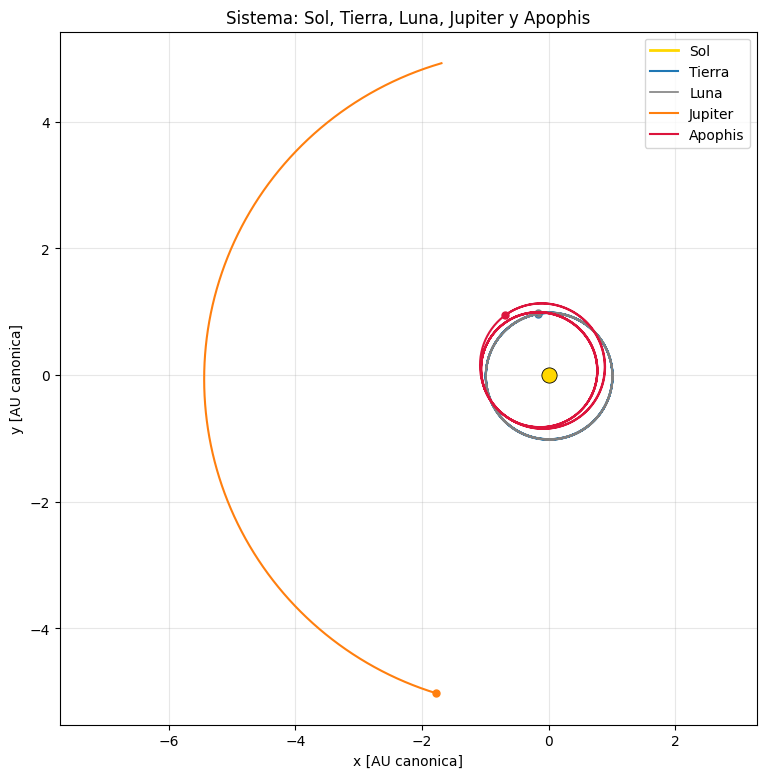

Energia cinetica (canonicas): 8.882309e-05
Energia potencial (canonicas): -1.820769e-04
Energia total del sistema (canonicas): -9.325378e-05


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
import pymcel as pc
import plotly.graph_objects as go


def consulta_estados_horizons(cuerpos, propiedades, epochs):
    """Consulta vectores de estado en SI desde Horizons para una lista de cuerpos."""
    estados_si = {}
    for nombre, obj_id in cuerpos:
        # consulta_horizons devuelve [x, y, z, vx, vy, vz]
        _, _, salida = pc.consulta_horizons(
            id=obj_id,
            location='@0',
            datos='vectors',
            propiedades=propiedades,
            epochs=epochs,
        )
        estados_si[nombre] = np.array(salida, dtype=float).reshape(-1)
    return estados_si


def convierte_a_unidades_canonicas(estados_si, masas_si, UL=1.495978707e11, UM=1.98847e30):
    """Convierte estados y masas desde SI a unidades canonicas."""
    UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)
    vel_unit = UL / UT

    estados_can = {}
    for nombre, vec in estados_si.items():
        x, y, z, vx, vy, vz = vec
        estados_can[nombre] = np.array([
            x / UL,
            y / UL,
            z / UL,
            vx / vel_unit,
            vy / vel_unit,
            vz / vel_unit,
        ])

    masas_can = {nombre: masas_si[nombre] / UM for nombre in masas_si}
    return estados_can, masas_can, UL, UM, UT, Gc


def simula_ncuerpos_rebound(cuerpos, estados_can, masas_can, Gc, UT, tmax_years=5.0, N=1200):
    """Rutina unica de simulacion N-cuerpos con REBOUND."""
    sim = rebound.Simulation()
    sim.integrator = 'ias15'
    sim.G = Gc

    names = [nombre for nombre, _ in cuerpos]
    for nombre in names:
        x, y, z, vx, vy, vz = estados_can[nombre]
        sim.add(
            m=masas_can[nombre],
            x=x,
            y=y,
            z=z,
            vx=vx,
            vy=vy,
            vz=vz,
            hash=nombre,
        )

    sim.move_to_com()

    tmax_si = tmax_years * 365.25 * 24 * 3600.0
    tmax_can = tmax_si / UT
    times = np.linspace(0.0, tmax_can, N)

    coords = {name: np.zeros((N, 2)) for name in names}
    rps = np.zeros((len(names), N, 3))

    for i, t in enumerate(times):
        sim.integrate(t)
        for j, name in enumerate(names):
            p = sim.particles[name]
            coords[name][i, 0] = p.x
            coords[name][i, 1] = p.y
            rps[j, i, 0] = p.x
            rps[j, i, 1] = p.y
            rps[j, i, 2] = p.z

    masas_arr = np.array([masas_can[name] for name in names])
    return sim, times, coords, rps, masas_arr


def calcula_energia_total(sim, Gc):
    """Calcula energia cinetica, potencial y total del estado actual."""
    particulas = sim.particles
    masas = np.array([p.m for p in particulas])
    velocidades = np.array([[p.vx, p.vy, p.vz] for p in particulas])
    posiciones = np.array([[p.x, p.y, p.z] for p in particulas])

    T = 0.5 * np.sum(masas * np.sum(velocidades**2, axis=1))

    U = 0.0
    npart = len(particulas)
    for i in range(npart):
        for j in range(i + 1, npart):
            ri = posiciones[i]
            rj = posiciones[j]
            rij = ri - rj
            dist_ij = np.linalg.norm(rij)
            U += -Gc * masas[i] * masas[j] / dist_ij

    E_total = T + U
    return T, U, E_total


def anima_ncuerpos(masas, rps, T, labels=None):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulacion

    if labels is None:
        labels = [f'Cuerpo {j+1}' for j in range(N)]
    elif len(labels) != N:
        raise ValueError('labels debe tener la misma longitud que el numero de cuerpos')

    # Colores de las particulas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animacion sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=labels[j],
            showlegend=True
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animacion 3D - {N} cuerpos - T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        legend=dict(title='Cuerpos', x=1.02, y=1.0),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()


def ejecuta_sistema(cuerpos, masas_si, epochs, propiedades, tmax_years=5.0, N=1200):
    """Horizons -> canonicas -> simulacion."""
    estados_si = consulta_estados_horizons(cuerpos, propiedades, epochs)
    estados_can, masas_can, UL, UM, UT, Gc = convierte_a_unidades_canonicas(estados_si, masas_si)
    sim, times, coords, rps, masas_arr = simula_ncuerpos_rebound(
        cuerpos=cuerpos,
        estados_can=estados_can,
        masas_can=masas_can,
        Gc=Gc,
        UT=UT,
        tmax_years=tmax_years,
        N=N,
    )
    return sim, times, coords, rps, masas_arr, UL, UM, UT, Gc, estados_can, masas_can


# Datos desde Horizons
epochs = '2026-01-01 00:00:00'

# Propiedades solicitadas a Horizons en unidades SI
propiedades = [
    ('x', 'm'), ('y', 'm'), ('z', 'm'),
    ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')
]

# Lista de cuerpos: (nombre_en_simulacion, id_horizons)
cuerpos = [
    ('Sol', '10'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Jupiter', '599'),
    ('Apophis', '99942'),
]

# Masas en SI [kg]
masas_si = {
    'Sol': 1.98847e30,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Jupiter': 1.89813e27,
    'Apophis': 3.4e10,
}

# Llamada  a rutinas para el sistema base
sim, times, coords, rps, masas_arr, UL, UM, UT, Gc, estados_can, masas_can = ejecuta_sistema(
    cuerpos=cuerpos,
    masas_si=masas_si,
    epochs=epochs,
    propiedades=propiedades,
    tmax_years=5.0,
    N=1200,
)

print('Unidades canonicas:')
print(f'  UL = {UL:.6e} m')
print(f'  UM = {UM:.6e} kg')
print(f'  UT = {UT:.6e} s')
print(f'  Gc = {Gc}')

# Grafica de trayectorias
plt.figure(figsize=(9, 9))
styles = {
    'Sol': dict(color='gold', lw=2.0),
    'Tierra': dict(color='tab:blue', lw=1.5),
    'Luna': dict(color='gray', lw=1.2),
    'Jupiter': dict(color='tab:orange', lw=1.5),
    'Apophis': dict(color='crimson', lw=1.5),
}

names = [nombre for nombre, _ in cuerpos]
for name in names:
    plt.plot(coords[name][:, 0], coords[name][:, 1], label=name, **styles[name])
    plt.scatter(coords[name][-1, 0], coords[name][-1, 1], s=25, color=styles[name]['color'])

plt.scatter(0, 0, color='gold', s=120, edgecolor='black', linewidth=0.6, zorder=5)
plt.title('Sistema: Sol, Tierra, Luna, Jupiter y Apophis')
plt.xlabel('x [AU canonica]')
plt.ylabel('y [AU canonica]')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Animacion 3D
anima_ncuerpos(masas_arr, rps, times[-1], labels=names)

# Energia total en unidades canonicas: E = T + U
T, U, E_total = calcula_energia_total(sim, Gc)

print(f'Energia cinetica (canonicas): {T:.6e}')
print(f'Energia potencial (canonicas): {U:.6e}')
print(f'Energia total del sistema (canonicas): {E_total:.6e}')

### Cálculo incluyendo a Urano

En esta celda se repite el procedimiento del modelo N-cuerpos, pero ahora se agrega **Urano** al sistema para evaluar su efecto en la energía cinética, potencial y total.

Sistema con Urano
Energia cinetica (canonicas): 8.996688e-05
Energia potencial (canonicas): -1.843581e-04
Energia total del sistema (canonicas): -9.439125e-05


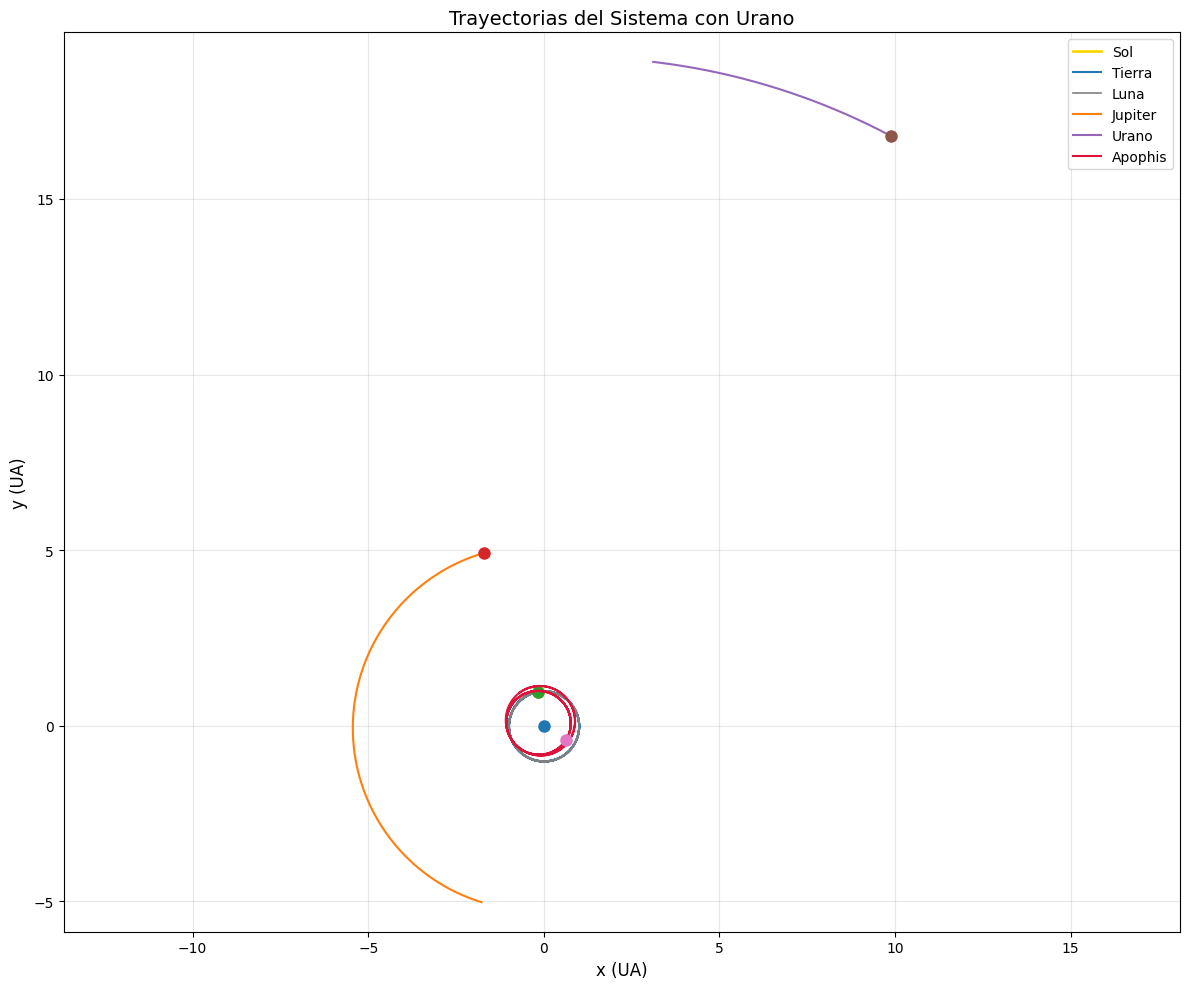

In [ ]:
epochs_u = '2026-01-01 00:00:00'
propiedades_u = [('x', 'm'), ('y', 'm'), ('z', 'm'), ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')]

# Cuerpos del sistema, ahora incluyendo Urano (ID Horizons = 799)
cuerpos_u = [
    ('Sol', '10'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Jupiter', '599'),
    ('Urano', '799'),
    ('Apophis', '99942'),
]

# Masas en SI [kg], incluyendo Urano
masas_si_u = {
    'Sol': 1.98847e30,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Jupiter': 1.89813e27,
    'Urano': 8.6810e25,
    'Apophis': 3.4e10,
}

# Llamada unica a rutinas para el sistema con Urano
sim_u, times_u, coords_u, rps_u, masas_arr_u, UL_u, UM_u, UT_u, Gc_u, estados_can_u, masas_can_u = ejecuta_sistema(
    cuerpos=cuerpos_u,
    masas_si=masas_si_u,
    epochs=epochs_u,
    propiedades=propiedades_u,
    tmax_years=5.0,
    N=1200,
)

# Energia mecanica total: E = T + U
T_u, U_u, E_total_u = calcula_energia_total(sim_u, Gc_u)

print('Sistema con Urano')
print(f'Energia cinetica (canonicas): {T_u:.6e}')
print(f'Energia potencial (canonicas): {U_u:.6e}')
print(f'Energia total del sistema (canonicas): {E_total_u:.6e}')

# Grafica de trayectorias
fig, ax = plt.subplots(figsize=(12, 10))

for nombre, _ in cuerpos_u:
    traj = coords_u[nombre]
    ax.plot(traj[:, 0], traj[:, 1], label=nombre, **styles.get(nombre, {}))
    ax.plot(traj[0, 0], traj[0, 1], 'o', markersize=8)

ax.set_xlabel('x (UA)', fontsize=12)
ax.set_ylabel('y (UA)', fontsize=12)
ax.set_title('Trayectorias del Sistema con Urano', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

# Animacion 3D
anima_ncuerpos(masas_arr_u, rps_u, times_u[-1], labels=[nombre for nombre, _ in cuerpos_u])

Sistema con todos los planetas (celda aparte)
Energia cinetica (canonicas): 1.093476e-04
Energia potencial (canonicas): -2.215985e-04
Energia total del sistema (canonicas): -1.122509e-04


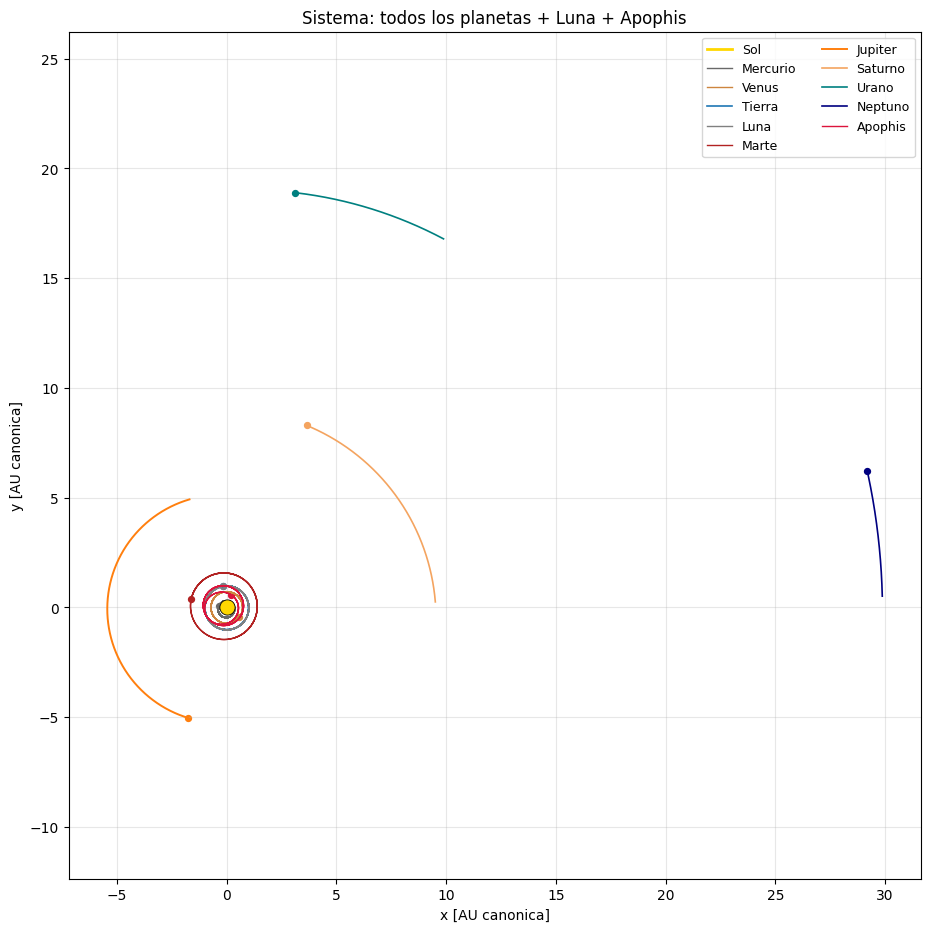

In [ ]:
# Todos los planetas

# Epoca y propiedades para consultar a Horizons
epochs_all = '2026-01-01 00:00:00'
propiedades_all = [('x', 'm'), ('y', 'm'), ('z', 'm'), ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')]

# Sol + 8 planetas + Luna + Apophis
cuerpos_all = [
    ('Sol', '10'),
    ('Mercurio', '199'),
    ('Venus', '299'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Marte', '499'),
    ('Jupiter', '599'),
    ('Saturno', '699'),
    ('Urano', '799'),
    ('Neptuno', '899'),
    ('Apophis', '99942'),
]

# Masas en SI [kg]
masas_si_all = {
    'Sol': 1.98847e30,
    'Mercurio': 3.3011e23,
    'Venus': 4.8675e24,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Marte': 6.4171e23,
    'Jupiter': 1.89813e27,
    'Saturno': 5.6834e26,
    'Urano': 8.6810e25,
    'Neptuno': 1.02413e26,
    'Apophis': 3.4e10,
}

# Llamada unica a rutinas para el sistema completo
sim_all, times_all, coords_all, rps_all, masas_arr_all, UL_all, UM_all, UT_all, Gc_all, estados_can_all, masas_can_all = ejecuta_sistema(
    cuerpos=cuerpos_all,
    masas_si=masas_si_all,
    epochs=epochs_all,
    propiedades=propiedades_all,
    tmax_years=5.0,
    N=1200,
)

# Energia: E = T + U
T_all, U_all, E_total_all = calcula_energia_total(sim_all, Gc_all)

print('Sistema con todos los planetas (celda aparte)')
print(f'Energia cinetica (canonicas): {T_all:.6e}')
print(f'Energia potencial (canonicas): {U_all:.6e}')
print(f'Energia total del sistema (canonicas): {E_total_all:.6e}')

# Grafica
styles_all = {
    'Sol': dict(color='gold', lw=2.0),
    'Mercurio': dict(color='dimgray', lw=1.0),
    'Venus': dict(color='peru', lw=1.0),
    'Tierra': dict(color='tab:blue', lw=1.2),
    'Luna': dict(color='gray', lw=1.0),
    'Marte': dict(color='firebrick', lw=1.0),
    'Jupiter': dict(color='tab:orange', lw=1.4),
    'Saturno': dict(color='sandybrown', lw=1.2),
    'Urano': dict(color='teal', lw=1.2),
    'Neptuno': dict(color='navy', lw=1.2),
    'Apophis': dict(color='crimson', lw=1.0),
}

names_all = [nombre for nombre, _ in cuerpos_all]
plt.figure(figsize=(11, 11))
for name in names_all:
    plt.plot(coords_all[name][:, 0], coords_all[name][:, 1], label=name, **styles_all[name])
    plt.scatter(coords_all[name][-1, 0], coords_all[name][-1, 1], s=18, color=styles_all[name]['color'])

plt.scatter(0, 0, color='gold', s=120, edgecolor='black', linewidth=0.6, zorder=5)
plt.title('Sistema: todos los planetas + Luna + Apophis')
plt.xlabel('x [AU canonica]')
plt.ylabel('y [AU canonica]')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.show()

# Animacion 3D
anima_ncuerpos(masas_arr_all, rps_all, times_all[-1], labels=[nombre for nombre, _ in cuerpos_all])

## Comparación energética de los tres sistemas

In [21]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# DataFrame comparativo de energias (unidades canonicas)
df_energia = pd.DataFrame([
    {
        'Sistema': 'Base (Sol-Tierra-Luna-Jupiter-Apophis)',
        'K cinetica': float(T),
        'U potencial': float(U),
        'E total': float(E_total),
        'Ligado (E<0)': bool(E_total < 0),
    },
    {
        'Sistema': 'Con Urano',
        'K cinetica': float(T_u),
        'U potencial': float(U_u),
        'E total': float(E_total_u),
        'Ligado (E<0)': bool(E_total_u < 0),
    },
    {
        'Sistema': 'Completo (8 planetas + Luna + Apophis)',
        'K cinetica': float(T_all),
        'U potencial': float(U_all),
        'E total': float(E_total_all),
        'Ligado (E<0)': bool(E_total_all < 0),
    },
])

df_mostrar = df_energia.copy()
for col in ['K cinetica', 'U potencial', 'E total']:
    df_mostrar[col] = df_mostrar[col].map(lambda x: f'{x:.6e}')

display(df_mostrar)

# Conclusion 
E_vals = df_energia['E total'].to_numpy(dtype=float)
K_vals = df_energia['K cinetica'].to_numpy(dtype=float)
U_vals = df_energia['U potencial'].to_numpy(dtype=float)
nombres = ['Sistema base', 'Sistema con Urano', 'Sistema con todos los planetas']

idx_mas_ligado = int(np.argmin(E_vals))
idx_mayor_absU = int(np.argmax(np.abs(U_vals)))
idx_mayor_K = int(np.argmax(K_vals))

texto_conclusion = (
    '### Conclusión\n'
    f'- En los tres casos, el criterio de ligadura es E < 0: {[bool(e < 0) for e in E_vals]}.\n'
    f'- El sistema mas ligado es **{nombres[idx_mas_ligado]}** (menor energia total).\n'
    f'- La mayor profundidad de potencial gravitacional corresponde a **{nombres[idx_mayor_absU]}** (mayor |U|).\n'
    f'- La mayor energia cinetica corresponde a **{nombres[idx_mayor_K]}**.\n'
    '- En conjunto, al incluir mas cuerpos relevantes, aumenta la interaccion gravitacional total y cambia el balance K-U del sistema.'
)

display(Markdown(texto_conclusion))

,Sistema,K cinetica,U potencial,E total,Ligado (E<0)
0,Base (Sol-Tierra-Luna-Jupiter-Apophis),8.882309e-05,-1.820769e-04,-9.325378e-05,True
1,Con Urano,8.996688e-05,-1.843581e-04,-9.439125e-05,True
2,Completo (8 planetas + Luna + Apophis),1.093476e-04,-2.215985e-04,-1.122509e-04,True


### Conclusión
- En los tres casos, el criterio de ligadura es E < 0: [True, True, True].
- El sistema mas ligado es **Sistema con todos los planetas** (menor energia total).
- La mayor profundidad de potencial gravitacional corresponde a **Sistema con todos los planetas** (mayor |U|).
- La mayor energia cinetica corresponde a **Sistema con todos los planetas**.
- En conjunto, al incluir mas cuerpos relevantes, aumenta la interaccion gravitacional total y cambia el balance K-U del sistema.